Question 3


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# initialisation

START = np.array([-1.5, 1.5], dtype=float)

BETA1 = 0.9
BETA2 = 0.999
EPS = 1e-8

ETA0 = 0.02

STEPS = 1000

K = 600
GAMMA = 0.9995
T_WARMUP = 100
ETA_MIN = 1e-4

FRAME_SKIP = 5


In [ ]:
# Rosenbrock and adam


def rosenbrock(p):
    x, y = p
    return (1 - x)**2 + 100 * (y - x**2)**2


def gradient(p):
    x, y = p

    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)

    return np.array([dx, dy])



def adam(point, lr, m, v, t):

    g = gradient(point)

    m = BETA1 * m + (1 - BETA1) * g
    v = BETA2 * v + (1 - BETA2) * g**2

    m_hat = m / (1 - BETA1**t)
    v_hat = v / (1 - BETA2**t)

    point = point - lr * m_hat / (np.sqrt(v_hat) + EPS)

    return point, m, v

In [ ]:
# The 5 lr schedules


def constant(t):
    return ETA0


def step_decay(t):
    return ETA0 * (0.1 ** ((t - 1) // K))


def exponential(t):
    return ETA0 * GAMMA**(t - 1)


def cosine(t):

    progress = (t - 1) / (STEPS - 1)

    return ETA_MIN + 0.5 * (ETA0 - ETA_MIN) * (
        1 + np.cos(np.pi * progress)
    )


def warmup_cosine(t):

    if t <= T_WARMUP:
        return ETA0 * t / T_WARMUP

    progress = (t - T_WARMUP) / (STEPS - T_WARMUP)

    return ETA_MIN + 0.5 * (ETA0 - ETA_MIN) * (
        1 + np.cos(np.pi * progress)
    )


schedules = {
    "Constant": constant,
    "Step Decay": step_decay,
    "Exponential": exponential,
    "Cosine": cosine,
    "Warmup + Cosine": warmup_cosine
}

In [ ]:
# Run

results = {}

for name, schedule in schedules.items():



    point = START.copy()

    m = np.zeros(2)
    v = np.zeros(2)

    trajectory = [point.copy()]
    losses = [rosenbrock(point)]
    learning_rates = []

    for t in range(1, STEPS + 1):

        lr = schedule(t)

        point, m, v = adam(
            point,
            lr,
            m,
            v,
            t
        )

        trajectory.append(point.copy())
        losses.append(rosenbrock(point))
        learning_rates.append(lr)

    results[name] = {
        "trajectory": np.array(trajectory),
        "loss": np.array(losses),
        "lr": np.array(learning_rates)
    }


print("finished.")



finished.


In [ ]:
# Rosenbrock contour


x = np.linspace(-2, 1.5, 300)
y = np.linspace(-1, 2.5, 300)

X, Y = np.meshgrid(x, y)

Z = (1 - X)**2 + 100 * (Y - X**2)**2

Z = np.clip(Z, 0, 5000)


# GIF 1


fig, ax = plt.subplots(figsize=(8, 6))

ax.contour(
    X,
    Y,
    Z,
    levels=20
)

ax.plot(
    1,
    1,
    marker="*",
    markersize=12,
    label="Minimum"
)

ax.set_xlim(-2, 1.5)
ax.set_ylim(-1, 2.5)

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_title("Adam on Rosenbrock")

lines = {}
dots = {}

for name in schedules:

    line, = ax.plot([], [], label=name)
    dot, = ax.plot([], [], "o")

    lines[name] = line
    dots[name] = dot

ax.legend(fontsize=8)

step_text = ax.text(
    0.02,
    0.95,
    "",
    transform=ax.transAxes
)


# Only 201 frames instead of 1001
frames = range(
    0,
    STEPS + 1,
    FRAME_SKIP
)


def update(frame):

    for name in schedules:

        path = results[name]["trajectory"]

        lines[name].set_data(
            path[:frame + 1, 0],
            path[:frame + 1, 1]
        )

        dots[name].set_data(
            [path[frame, 0]],
            [path[frame, 1]]
        )

    step_text.set_text(
        f"Step: {frame}"
    )

    return (
        list(lines.values())
        + list(dots.values())
        + [step_text]
    )


animation = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=30,
    blit=True
)

animation.save(
    "rosenbrock_trajectories.gif",
    writer=PillowWriter(fps=20)
)

plt.close(fig)

print(" GIF 1 saved.")

 GIF 1 saved.


In [ ]:
# GIF 2


fig, ax = plt.subplots(figsize=(8, 5))

steps = np.arange(1, STEPS + 1)

ax.set_xlim(1, STEPS)
ax.set_ylim(0, ETA0 * 1.1)

ax.set_xlabel("Step")
ax.set_ylabel("Learning rate")

ax.set_title("Adam Learning-Rate Schedules")

lr_lines = {}
lr_dots = {}

for name in schedules:

    lr_values = results[name]["lr"]

    line, = ax.plot(
        steps,
        lr_values,
        label=name
    )

    dot, = ax.plot([], [], "o")

    lr_lines[name] = line
    lr_dots[name] = dot

ax.legend(fontsize=8)


def update_lr(frame):

    for name in schedules:

        lr = results[name]["lr"][frame]

        lr_dots[name].set_data(
            [frame + 1],
            [lr]
        )

    return list(lr_dots.values())


animation_lr = FuncAnimation(
    fig,
    update_lr,
    frames=range(0, STEPS, FRAME_SKIP),
    interval=30,
    blit=True
)

animation_lr.save(
    "learning_rate_schedules.gif",
    writer=PillowWriter(fps=20)
)

plt.close(fig)

print("GIF 2 saved.")

GIF 2 saved.


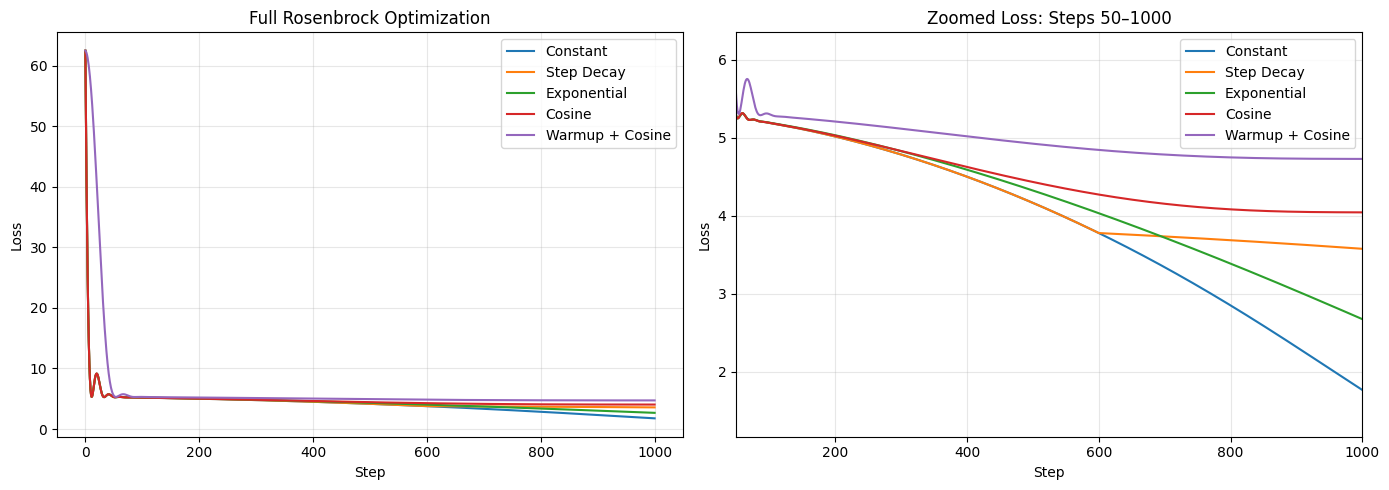

In [ ]:


fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

# Full loss curve

for name in schedules:
    ax1.plot(
        results[name]["loss"],
        label=name
    )

ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.set_title("Full Rosenbrock Optimization")
ax1.legend()
ax1.grid(alpha=0.3)


# Zoomed loss curve

for name in schedules:
    ax2.plot(
        results[name]["loss"],
        label=name
    )

ax2.set_xlim(50, 1000)

zoom_losses = np.concatenate([
    results[name]["loss"][50:]
    for name in schedules
])

y_min = zoom_losses.min()
y_max = zoom_losses.max()

margin = (y_max - y_min) * 0.15

ax2.set_ylim(
    y_min - margin,
    y_max + margin
)

ax2.set_xlabel("Step")
ax2.set_ylabel("Loss")
ax2.set_title("Zoomed Loss: Steps 50–1000")
ax2.legend()
ax2.grid(alpha=0.3)


plt.tight_layout()

plt.savefig(
    "loss_vs_step_clear.png",
    dpi=200
)

plt.show()

The schedules-



*   Constant- Employs a constant learning rate throughout the optimisation. This is very fast as compared to the others that go down in value gradually. However, due to this, it may overshoot after reaching the minimum.
*   Step Decay- Decays by a factor every certian number of steps (600 here). Here, it dacays too quickly to reach the end.
*  Exponential- Employs an exponential decay. Here, it decays much faster than the step.
* Cosine- Decays in a behavior defined by 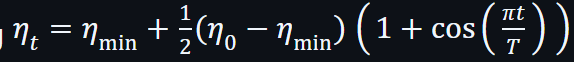. Here it also performs worse than constant.

* Linear warmup plus cosine decay- Same as cosine but with an even slower initatial learning rate. This saves Cosine decay during the first few steps when it is very sensitive. Here though it just performs worse.

so tl;dr- Constant performs best, and no, linear warmup does not help during the first few steps. This makes sense for Rosenbrock surface, which is notorious for stalling progression.





